In [2]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# 1-3 Modeling Linear Data

1. The CSV file named `'trend1.csv'` is read into the Pandas Dataframe `df` for you below.
Using **statsmodel's formula API**, fit a linear model between the INPUT `x` and OUTPUT `y1`. You may assume that all conditions to apply a linear model are satisfied. Store the resulting fitted model into the variable `lm_fit`. Print the summary statistics of `lm_fit`.

What is the estimated coefficient for x?

In [4]:
# STARTER
df = pd.read_csv("trend1.csv")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       101 non-null    float64
 1   y1      101 non-null    float64
 2   y2      101 non-null    float64
 3   y3      101 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


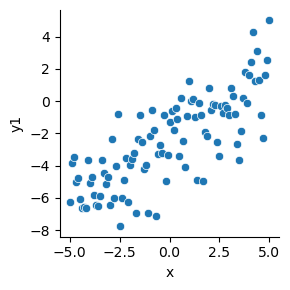

In [5]:
sns.relplot(data=df, x='x', y='y1', height=3)
plt.show()

In [12]:
lm_fit = smf.ols(formula = 'x ~ y1', data = df).fit()

In [13]:
lm_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      x   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     151.8
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.07e-21
Time:                        06:21:41   Log-Likelihood:                -204.45
No. Observations:                 101   AIC:                             412.9
Df Residuals:                      99   BIC:                             418.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9964      0.245      8.140      0.000       1.510       2.483
y1             0.8150      0.066     12.320      0.000       0.684       0.946
==============================================================================
Omnibus:                        1.336   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.513   Jarque-Bera (JB):                1.345
Skew:                           0.267   Prob(JB):                        0.510
Kurtosis:                       2.814   Cond. No.                         5.10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
lm_fit.params

Intercept    1.996377
y1           0.814969
dtype: float64

2. The CSV file named `'trend1.csv'` is read into the Pandas Dataframe `df` for you below.
Using seaborn, plot a **scatterplot** showing the relationship between `y2` and `x`.

Which common function would best fit the relationship between `y2` and `x`?

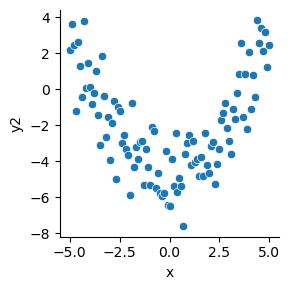

In [9]:
sns.relplot(data=df, x='x', y='y2', height=3)
plt.show()

In [10]:
model = smf.ols(formula = 'x ~ y2', data = df).fit()


In [11]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      x   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.04739
Date:                Fri, 10 Apr 2026   Prob (F-statistic):              0.828
Time:                        06:20:33   Log-Likelihood:                -251.36
No. Observations:                 101   AIC:                             506.7
Df Residuals:                      99   BIC:                             512.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0475      0.365      0.130      0.897      -0.677       0.772
y2             0.0233      0.107      0.218      0.828      -0.189       0.235
==============================================================================
Omnibus:                       34.225   Durbin-Watson:                   0.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                6.108
Skew:                          -0.050   Prob(JB):                       0.0472
Kurtosis:                       1.799   Cond. No.                         4.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

3. The CSV file named 'trend1.csv' is read into the Pandas Dataframe df for you below. Using the feature you identified in question 1, fit a linear model that best approximates the relationship between `y2` and `x`. Store the resulting fitted model into the variable `lm_fit`. We will cover this later in the course, but you can incorporate nonlinear functions by replacing `x` in a Statsmodels formula like `y2 ~ x` with:
    - For x squared, use **np.power(x, 2)**

    - For √x, use **np.sqrt(x)**

    - For sin(x), use **np.sin(x)**



After fitting this model, print the p-values of `lm_fit`.

Assuming a 95% confidence level, are the coefficients for the intercept and feature of `x` statistically significant?

In [18]:
model = smf.ols('y2 ~ np.power(x, 2)', data=df).fit()


In [22]:
model.params

Intercept        -4.675921
np.power(x, 2)    0.310287
dtype: float64

In [23]:
model.pvalues

Intercept         2.450706e-40
np.power(x, 2)    7.651285e-31
dtype: float64

In [19]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y2   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     284.0
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           7.65e-31
Time:                        06:31:20   Log-Likelihood:                -176.77
No. Observations:                 101   AIC:                             357.5
Df Residuals:                      99   BIC:                             362.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.6759      0.210    -22.270      0.000      -5.093      -4.259
np.power(x, 2)     0.3103      0.018     16.851      0.000       0.274       0.347
==============================================================================
Omnibus:                        0.636   Durbin-Watson:                   2.316
Prob(Omnibus):                  0.728   Jarque-Bera (JB):                0.727
Skew:                           0.025   Prob(JB):                        0.695
Kurtosis:                       2.587   Cond. No.                         17.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

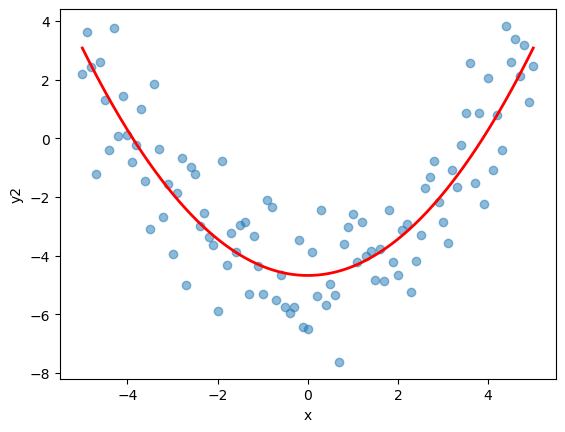

In [20]:
x_range = np.linspace(df['x'].min(), df['x'].max(), 300)
y2_pred = model.predict(pd.DataFrame({'x': x_range}))

plt.scatter(df['x'], df['y2'], alpha=0.5, label='Actual data')
plt.plot(x_range, y2_pred, color='red', linewidth=2, label='OLS fit')
plt.xlabel('x')
plt.ylabel('y2')
plt.show()

In [ ]:
# STARTER
df = pd.read_csv("trend1.csv")

# SOLUTION
